# System 2: $V(r) = -10\exp(-r^2)$, $s$-wave bound state, wide $p$-wave resonance.
- Supports an $s$-wave bound state at $E_b=-2.54340$.
- Supports a $p$-wave resonance at $E_r=0.25823 - i0.16433$
    - $\phi_\text{min}=\text{arg}(E) / 2 \approx 0.28336$.
    - $V(r)$ is a Gaussian, so $\phi_\text{max}=\pi/4\approx0.785$
- $\phi_\text{min} \le \phi < \phi_\text{max} = 0.28336 \le \phi < 0.785$.
- By $r=5$, $V(r=10)\propto 10^{-10} \approx 0$.

Due to finite volume effects, the good region of $\phi$ might vary from its theoretical value. This is a very narrow resonance. This gives
EC a much larger region to train over and a much smaller gap to extrapolate across for back-rotation.

In [1]:
from src.dvr import DVR

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# define system parameters
n = 1024                         # number of DVR grid points
phi = np.pi / 6                       # rotation angle (0.567/2, 0.785) or (arg(real_res)/2, pi/4)
real_res = 0.25823 - 1j*0.16433  # expected value of resonance
real_bound = -2.5434016 + 1j*0   # due to finite volume, there will be a small imaginary component from CSM
L = 50.0                         # system size

gauss_p = lambda r: -10 * exp(-r**2) # potential (supports a p-wave resonance and s-wave bound state)

### Plot of the good region of $\phi$ for system 2

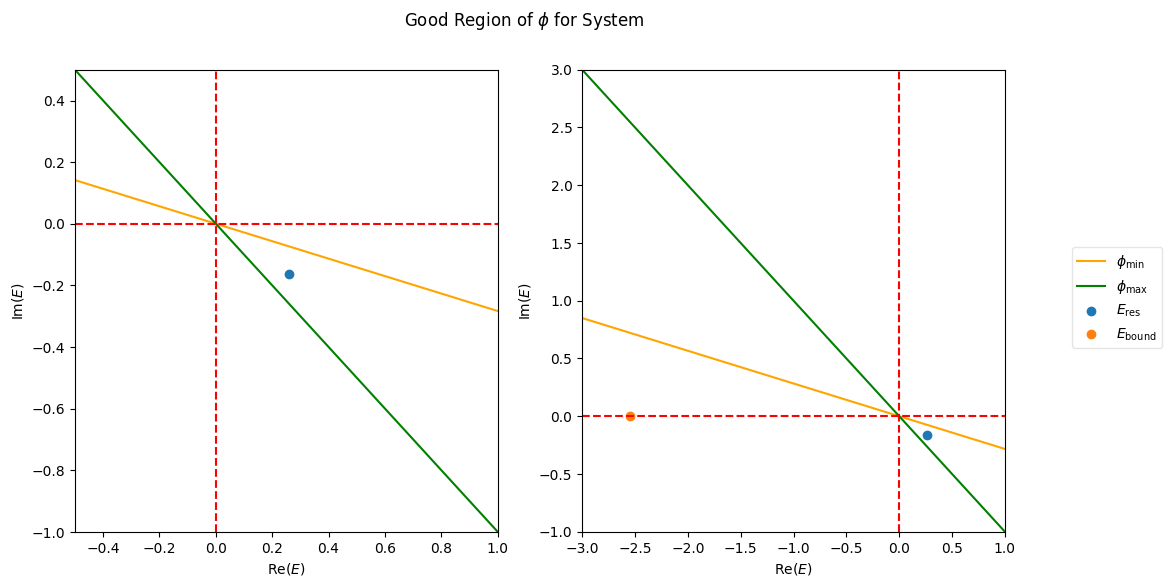

In [3]:
fig, (axres, axbound) = plt.subplots(1, 2, figsize=(12,6))
axres.set_xlim([-.5, 1.0])
axres.set_ylim([-1.0, 0.5])
axbound.set_xlim([-3.0, 1.0])
axbound.set_ylim([-1.0, 3.0])
for ax in (axres, axbound):
    ax.axline((0,0), (1, np.angle(real_res)/2), color='orange', label=r'$\phi_\text{min}$')
    ax.axline((0,0), (1, -np.tan(np.pi/4)), color='green', label=r'$\phi_\text{max}$')
    ax.axvline(0, linestyle='--', color='red')
    ax.axhline(0, linestyle='--', color='red')
    ax.scatter(np.real(real_res), np.imag(real_res), label=r'$E_\text{res}$')
    ax.set_xlabel(r"Re$(E)$")
    ax.set_ylabel(r"Im$(E)$")
    ax.legend().remove()
axbound.scatter(np.real(real_bound), np.imag(real_bound), label=r'$E_\text{bound}$')
fig.suptitle(r"Good Region of $\phi$ for System ")
handles, labels = axbound.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.95, 0.5), framealpha=0.5)
plt.show()

### $E(L)$ and $(r_\theta^2)(L)$ at fixed $\phi$.
We plot $E$ and $(r_\theta^2)$ across several $L$ at a fixed $\phi$ in the "good" complex-scaling window ($\phi= \pi/6\approx0.52$). Both observables converge to a constant value as $L$ increases, consistent with standard results in finite-volume physics. We note that the observables tend to oscillate around a central value, with the envelope of the oscillations damping as $L$ increases.

In [4]:
# compute <r^2> as L varies
Ls = np.linspace(20.0, 50.0, 150)
energies, rrs = [], []

for L in Ls:
    DVRtest = DVR(n, L, rotation_angle=phi, potential=gauss_s)
    energy, eigstate = DVRtest.closest_to_resonance(real_res)
    rr = DVRtest.compute_rr(eigstate[:, 0], rotate_rr=True)
    energies.append(energy)
    rrs.append(rr)

NameError: name 'gauss_s' is not defined

In [ ]:
# plot E(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(energies))
ax2.plot(Ls, np.imag(energies))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(r"$E(L)$ at $\phi=\pi/24$ for System 2")
plt.show()

# plot <r^2>(L)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(Ls, np.real(rrs))
ax2.plot(Ls, np.imag(rrs))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$L$")
fig.suptitle(r"$\langle r^2\rangle(L)$ at $\phi=\pi/24$ for System 2")
plt.show()

### $E(\phi)$ and $(r^2)(\theta)$ at fixed $L$
We plot $E$ and $(r^2)$ across several $\phi$ in the "good" complex-scaling window, at a fixed, well-converged box size ($L=50$). Both observables are nearly $\phi$-dependent over a central subset of this window, consistent with the ABC theorem. But, they degrade near the edges, before the theoretical minimum and maximum are reached. 

Near $\phi_\text{min}$ approaches $\phi_\text{min}$, coupling with the finite-volume continuum states can contaminate the data. After complex scaling, $V(r)\propto \exp(-r^2\cos(2\theta))$. $As $\phi$ approaches $\phi_\text{max}$, the radial extent instability can contaminate the data before the theoretical maximum is actually reached.

In [ ]:
# compute E and <r^2> as phi varies
# the ABC theorem says that this should be const.
phis = np.linspace(0.3, 0.7, 50)
energies, rrs = [], []

for phi in phis:
    DVRtest = DVR(n, L, rotation_angle=phi, potential=gauss_s)
    energy, eigstate = DVRtest.closest_to_resonance(real_res)
    rr = DVRtest.compute_rr(eigstate[:, 0], rotate_rr=True)
    energies.append(energy)
    rrs.append(rr)

In [ ]:
# plot <E>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(energies))
ax2.plot(phis, np.imag(energies))
ax1.set_ylabel(r"Re$(E)$")
ax2.set_ylabel(r"Im$(E)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(r"$E$ at $L$=50.0 for System 2")
plt.show()

# plot <r^2>(phi)
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(phis, np.real(rrs))
ax2.plot(phis, np.imag(rrs))
ax1.set_ylabel(r"Re$(\langle r^2\rangle)$")
ax2.set_ylabel(r"Im$(\langle r^2\rangle)$")
ax2.set_xlabel(r"$\phi$")
fig.suptitle(r"$\langle r^2\rangle(\phi)$ at $L$=50.0 for System 2")
plt.show()

### $|E(L) - E(L_\text{max})|$ and $|(r_\phi^2)(L) - (r_\phi^2)(L_\text{max})|$ for several $\phi$
We plot the residual of the observables from their large-volume limits at several $L$ for a few $\phi$. Both $E(L_\text{max})$ and $(r_\phi^2)(L_\text{max})$ are taken at a fixed $\phi$ value wherein the value is accurate ($\phi=\pi/6$).

In [ ]:
# compute E and <r^2> as L varies
phis = np.linspace(0.3, 0.70, 5)
Ls = np.linspace(20.0, 50.0, 150)

reference_dvr = DVR(n, L=50.0, rotation_angle=np.pi/6, potential=gauss_s)
reference_energy, eigstate = reference_dvr.closest_to_resonance(real_res)
reference_rr = reference_dvr.compute_rr(eigstate[:, 0], rotate_rr=True)

energies_resid, rrs_resid = [], []
for phi in phis:
    energies_L, rrs_L = [], []
    for L in Ls:
        DVRtest = DVR(n, L, rotation_angle=phi, potential=gauss_s)
        energy, eigstate = DVRtest.closest_to_resonance(real_res)
        rr = DVRtest.compute_rr(eigstate[:, 0], rotate_rr=True)
        energies_L.append(energy)
        rrs_L.append(rr)
    energies_resid.append(energies_L - reference_energy)
    rrs_resid.append(rrs_L - reference_rr)
energies_resid = np.array(energies_resid)
rrs_resid = np.array(rrs_resid)

In [ ]:
# plot E residual
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
for i, phi in enumerate(phis):
    ax1.plot(Ls, np.real(energies_resid[i]), label=rf'$\phi$={phi:.3f}')
    ax2.plot(Ls, np.imag(energies_resid[i]))
ax1.set_ylabel(r"|Re$(E(L)-E(L_\text{max}))$|")
ax2.set_ylabel(r"|Im$(E(L) - E(L_\text{max}))$|")
ax2.set_xlabel(r"$L$")
ax1.set_yscale("symlog", linthresh=1e-6)
ax2.set_yscale("symlog", linthresh=1e-6)
fig.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
fig.suptitle(r"$|E(L) - E(L_\text{max})|$ for System 2")
plt.show()

# plot (r^2) residual
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
for i, phi in enumerate(phis):
    ax1.plot(Ls, np.real(rrs_resid[i]), label=rf'$\phi$={phi}')
    ax2.plot(Ls, np.imag(rrs_resid[i]))
ax1.set_ylabel(r"|Re$(\langle r_\phi^2\rangle(L) - \langle r_\phi^2\rangle(L_\text{max}))|$")
ax2.set_ylabel(r"|Im$(\langle r_\phi^2\rangle(L) - \langle r_\phi^2\rangle(L_\text{max}))|$")
ax2.set_xlabel(r"$L$")
ax1.set_yscale("symlog", linthresh=1e-6)
ax2.set_yscale("symlog", linthresh=1e-6)
fig.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))
fig.suptitle(r"|$\langle r_\phi^2\rangle(L) - \langle r_\phi^2\rangle(L_\text{max})|$ for System 2")
plt.show()